In [10]:
import pandas as pd
import geopandas as gpd
from unidecode import unidecode

import matplotlib.pyplot as plt
import seaborn as sns

import climattr as eea

In [6]:
ips_data = pd.read_csv('data/ips_brasil_municipios.csv')

ips_data['Município'] = ips_data['Município'].apply(lambda x: str(unidecode(x)).upper()[:-5])
ips_data['city_residency'] = ips_data['UF'] + '_' + ips_data['Município']

columns = ['Água e Saneamento', 'PIB per capita 2021',]
ips_data = ips_data[['city_residency'] + columns].rename(columns={'Água e Saneamento': 'water_sanitation', 'PIB per capita 2021': 'pib_2021'})

dummy_data = pd.read_csv('data/ips_brasil_municipios.csv')
dummy_data['Código IBGE'] = dummy_data['Código IBGE'].astype(str)

dummy_data['Município'] = dummy_data['Município'].apply(lambda x: str(unidecode(x)).upper()[:-5])
dummy_data['city_residency'] = dummy_data['UF'] + '_' + dummy_data['Município']

urban_pop = gpd.read_file('utils/sidra_9923_PercPopResidUrbana_mun_22_polPolygon.shp')
urban_pop = urban_pop.set_index('Geocodigo').join(dummy_data.set_index('Código IBGE')[['UF']]).reset_index()

urban_pop['Nome'] = urban_pop['Nome'].apply(lambda x: str(unidecode(x)).upper())
urban_pop['city_residency'] = urban_pop['UF'] + '_' + urban_pop['Nome']

columns = ['PercPopRes', 'PopResidUr']
urban_pop = urban_pop[['city_residency'] + columns].rename(columns={'PercPopRes': 'percent_urban', 'PopResidUr': 'urban_pop'})

inc = pd.read_csv('data/model_input_brazil_immunity_city.csv')

inc = inc.groupby(['region', 'city_residency']).mean(numeric_only=True).reset_index()
inc = inc[['city_residency', 'dengue_inc', 'region']]


In [11]:
df = ips_data.set_index('city_residency').join(urban_pop.set_index('city_residency')).join(inc.set_index('city_residency')).reset_index()

gdf = gpd.read_file('../supplementary/shapefiles/municipios/municipios.shp')
gdf['city_name'] = gdf['SIGLA_UF'] + '_' + gdf['city_name']

df = eea.impacts.geolocate_dataframe(df, gdf, 'city_residency', 'city_name')


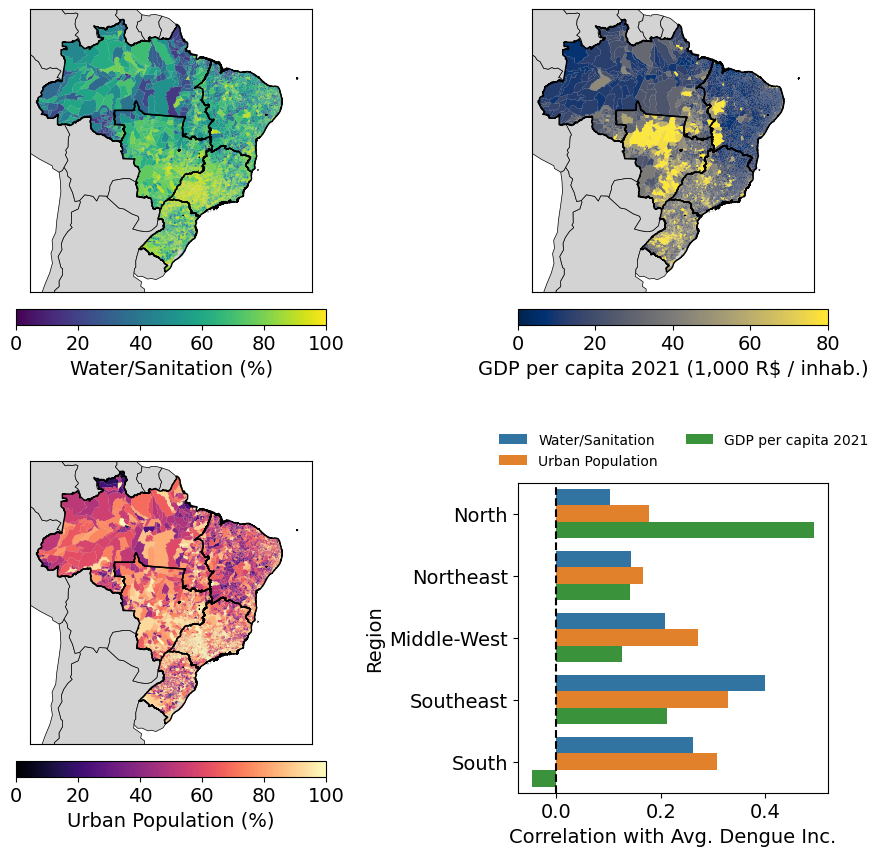

In [13]:
plt.rcParams.update({'font.size': 14})

south_american_countries = [
    "Argentina",
    "Bolivia",
    "Brazil",
    "Chile",
    "Colombia",
    "Ecuador",
    "Guyana",
    "Paraguay",
    "Peru",
    "Suriname",
    "Uruguay",
    "Venezuela",
    "French Guiana",  # Technically an overseas department of France, but often included in geographical maps
    "France"
]

world = gpd.read_file('utils/ne_110m_admin_0_countries/ne_110m_admin_0_countries.shp')
south_america = world[world['SOVEREIGNT'].isin(south_american_countries)]

region = gpd.read_file('utils/BR_UF_2022/BR_UF_2022.shp')
region_agg = region.dissolve(by='NM_REGIAO')

fig, [[ax1, ax2], [ax3, ax4]] = plt.subplots(2, 2, figsize=(9,9))

df['pib_2021_th'] = df['pib_2021'].astype(float) / 1000

# Brazil map on the left (spans both rows in column 0)
for ax in [ax1, ax2, ax3]:
    south_america.plot(ax=ax, color='lightgrey', edgecolor='black', lw=0.5)

plot = df.plot(
    ax=ax1, 
    column='water_sanitation', 
    vmin=0,
    vmax=100,
    cmap='viridis',
    legend=True,
    legend_kwds={"label": "Water/Sanitation (%)", "orientation": "horizontal", "pad": 0.05, 'shrink': 1.0}
)

plot = df.plot(
    ax=ax2, 
    column='pib_2021_th', 
    vmin=0,
    vmax=80,
    cmap='cividis',
    legend=True,
    legend_kwds={"label": "GDP per capita 2021 (1,000 R$ / inhab.)", "orientation": "horizontal", "pad": 0.05, 'shrink': 1.0}
)

plot = df.plot(
    ax=ax3, 
    column='percent_urban', 
    vmin=0,
    vmax=100,
    cmap='magma',
    legend=True,
    legend_kwds={"label": "Urban Population (%)", "orientation": "horizontal", "pad": 0.05, 'shrink': 1.0}
)

corr = df.groupby('region').corr(numeric_only=True, method='spearman')['dengue_inc'].reset_index()
corr = corr[corr['level_1'].isin(['water_sanitation', 'pib_2021_th', 'percent_urban'])]
corr['level_1'] = corr['level_1'].replace({
    'water_sanitation': 'Water/Sanitation',
    'pib_2021_th': 'GDP per capita 2021',
    'percent_urban': 'Urban Population'
})

sns.barplot(
    y='region', x='dengue_inc', hue='level_1', ax=ax4, data=corr,
    order=['North', 'Northeast', 'Middle-West', 'Southeast', 'South'],
)

ax4.axvline(0, color='k', linestyle='--')
ax4.set_xlabel('Correlation with Avg. Dengue Inc.')
ax4.set_ylabel('Region')
ax4.legend(fontsize=10, ncol=2, bbox_to_anchor=(-0.1, 1.2), loc='upper left', frameon=False)

for ax in [ax1, ax2, ax3]:
    region_agg.plot(ax=ax, color='none', edgecolor='black', lw=1)

    ax.set_xlim([-75, -30])
    ax.set_ylim([-35, 5])
    ax.set_xticks([])
    ax.set_yticks([])

for ax in [ax1, ax2, ax3, ax4]:
    ax.set_box_aspect(1)   # same height/width

plt.tight_layout()
plt.savefig('img/brazil_socioeconomic.pdf', dpi=300, bbox_inches='tight')
